# **Final Notebook: Baseline Global Feature Model**

In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.global_feature_extractor import SurgicalFeatureExtractor
from src_final.models.analysis import leakage_free_correlation_analysis, leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [2]:
# file paths
processed_dir="data/processed/landmark_dataframes/"
ratings_csv="data/scores/merged_scores.csv"

# create scores dataframe
df_ratings = pd.read_csv(ratings_csv)

# create all metrics dataframe
end = "_30fps_processed.pkl"
processed_files = sorted([f for f in os.listdir(processed_dir) if f.endswith(end)])
all_metrics = []

for filename in tqdm(processed_files):
    # Load raw tracking data
    df_raw = pd.read_pickle(os.path.join(processed_dir, filename))
    
    # Initialize and compute in one step
    extractor = SurgicalFeatureExtractor(df_raw, fps=30, min_disp=0, vel_threshold=40)
    
    # Get the 1-row dataframe of features
    feats = extractor.features_df
    feats["file"] = filename.replace('hand_tracking_', '').replace(end, '') # Add identifier
    
    all_metrics.append(feats)

# Combine all videos
df_all_metrics = pd.concat(all_metrics, ignore_index=True)

# Merge with scores (as you did before)
df_full = pd.merge(df_all_metrics, df_ratings, left_on="file", right_on="Vid_Name").drop(columns=["file"])

100%|██████████| 86/86 [00:24<00:00,  3.57it/s]


In [3]:
# remove a participant for reason to verify
df_full = df_full[df_full["Participant Number"] != 8]

## Use top Features Only
Extract features that are highly correlated with scores (>0.6) over all folds

In [4]:
# correlation between features and scores
all_features = [col for col in df_full if col not in df_ratings.columns]
fair_corr_df = leakage_free_correlation_analysis(df_full, all_features, n=6)
fair_corr_df

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 41.63it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
18,num_reversals_Right,-0.718384,0.011447,-0.752266,-0.705991,1.000000
31,total_duration_Left,-0.684729,0.011293,-0.714053,-0.666340,1.000000
32,total_duration_Right,-0.684197,0.011335,-0.713487,-0.665757,1.000000
16,nmu_peaks_Right,-0.678805,0.013019,-0.715874,-0.660553,1.000000
34,total_path_Right,-0.669737,0.014455,-0.708289,-0.651589,1.000000
8,ldlj_smoothness_Left,0.638477,0.015777,0.610076,0.688787,0.785714
17,num_reversals_Left,-0.628779,0.014508,-0.656598,-0.592668,0.142857
15,nmu_peaks_Left,-0.624045,0.013900,-0.645851,-0.596150,0.035714
30,total_angular_path_Right,-0.617772,0.012847,-0.646571,-0.601983,0.035714
9,ldlj_smoothness_Right,0.616430,0.011857,0.591682,0.639987,0.000000


In [5]:
top_features = fair_corr_df[(abs(fair_corr_df['Min_Corr_with_Target']) > 0.6) & (abs(fair_corr_df['Max_Corr_with_Target']) > 0.6)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full[top_features].corr()

# if over 97.5% correlated, drop second feature
to_drop = set()
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        feat1 = top_features[i]
        feat2 = top_features[j]
        if abs(inter_corrs.loc[feat1, feat2]) > 0.98:
            to_drop.add(feat2)

to_drop

top_right = [feat for feat in top_features if 'Right' in feat]

top_features = [feat for feat in top_features if feat not in to_drop]

# Try Some Models with these Features
- using all features
- using only the top correlated features

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 75.98it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7014 | MAE: 5.3341 | MAE STD: 4.1589 | R2: 0.4720


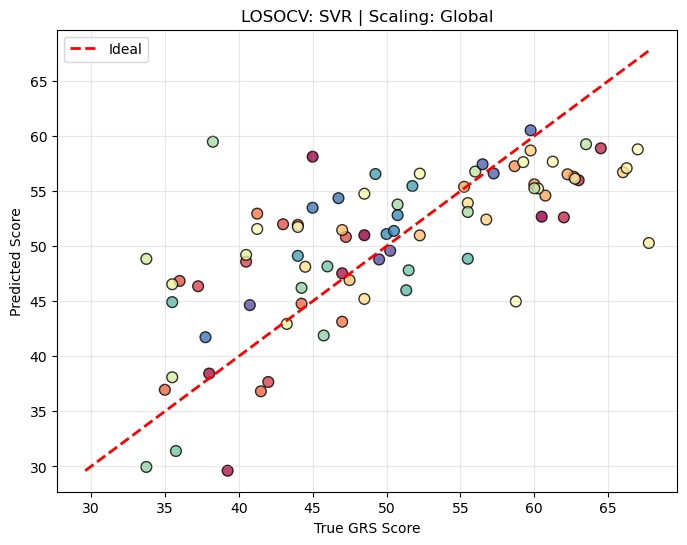

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 145.77it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7148 | MAE: 5.3033 | MAE STD: 4.0791 | R2: 0.4833


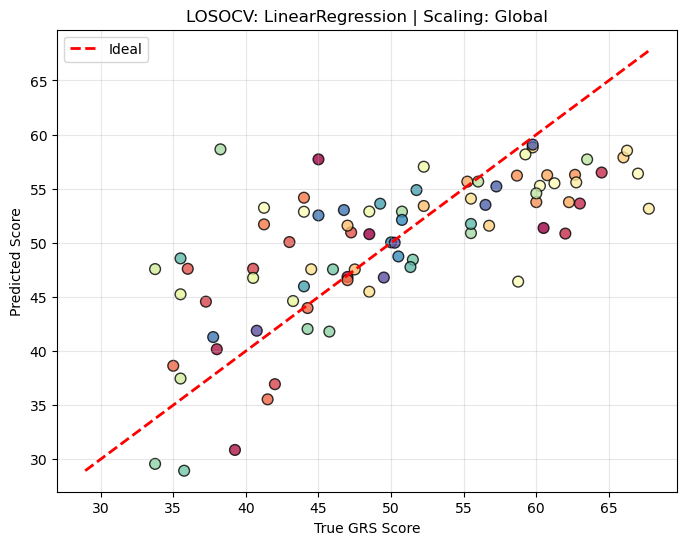

In [6]:
# Ridge
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
_, _, _ = evaluate_loso_model(df_full, top_features, model_class=SVR, model_params={'kernel':'linear', 'C':0.5, 'epsilon':0.1})
_, _, _ = evaluate_loso_model(df_full, ['num_reversals_Right'], model_class=LinearRegression, model_params={})

# All Top Features are Highly Inter-Correlated
- Remove very redundant ones > 97.5% corr
- PCA with the remaining ones

In [7]:
# keep first
top_features = [feat for feat in top_features if feat not in to_drop]


scaler = StandardScaler()
X = scaler.fit_transform(df_all_metrics[top_features].values)

pca = PCA(n_components=len(top_features))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features)
df['Explained_Variance'] = explained_variance
df

,num_reversals_Right,total_duration_Left,nmu_peaks_Right,total_path_Right,ldlj_smoothness_Left,total_angular_path_Right,Explained_Variance
0,0.429387,0.412514,0.426280,0.418118,-0.369285,0.390577,0.862051
1,0.179243,-0.269810,0.218840,0.324314,0.816651,0.274016,0.067405
2,-0.218177,-0.253502,-0.194332,-0.278595,-0.162996,0.863821,0.039724
3,-0.105694,0.822117,-0.190660,-0.291259,0.409558,0.155021,0.018363
4,-0.207544,0.088109,-0.659797,0.713749,-0.047493,0.046237,0.007871
5,0.825622,-0.095558,-0.510829,-0.219348,0.012180,-0.002879,0.004587


In [8]:
top_features

['num_reversals_Right',
 'total_duration_Left',
 'nmu_peaks_Right',
 'total_path_Right',
 'ldlj_smoothness_Left',
 'total_angular_path_Right']

## Model With PCA features

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 47.07it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7092 | MAE: 5.2684 | MAE STD: 4.0713 | R2: 0.4883


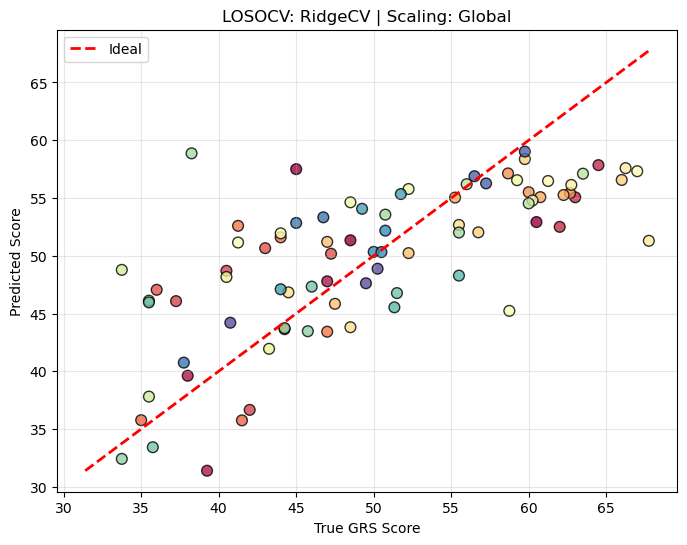

In [9]:
_, _, _ = evaluate_loso_model(df_full, top_features, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

## How Well Do the Remaining Features Explain the Residuals of PC1 Model?

In [10]:
candidate_features = [feat for feat in all_features if feat not in top_features]
#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features, candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.82it/s]


,Feature,Type,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Selection_Stability
34,velocity_corr,External,0.120221,0.017269,-0.330655,1.0
4,PCA_Comp_6,PC,0.047102,0.008062,-0.216257,0.0
35,velocity_ratio,External,0.042269,0.011263,-0.203411,0.0
22,orientation_entropy_Right,External,0.021125,0.005771,-0.141941,0.0
23,pose_variability_Left,External,0.019369,0.006824,-0.129278,0.0
29,stationary_time_ratio_Left,External,0.015872,0.006145,0.119159,0.0
25,rms_accel_Left,External,0.015151,0.005055,-0.115461,0.0
20,num_reversals_Left,External,0.012582,0.005487,-0.064694,0.0
7,fraction_tracked_Left,External,0.012179,0.004765,0.103173,0.0
27,rotation_over_dist_Left,External,0.011679,0.006665,-0.104669,0.0


In [11]:
top_features

['num_reversals_Right',
 'total_duration_Left',
 'nmu_peaks_Right',
 'total_path_Right',
 'ldlj_smoothness_Left',
 'total_angular_path_Right']

### Hybrid Model PC1 + Velocity Corr

Significant imporvement!

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 46.14it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7476 | MAE: 5.1477 | MAE STD: 3.7885 | R2: 0.5285


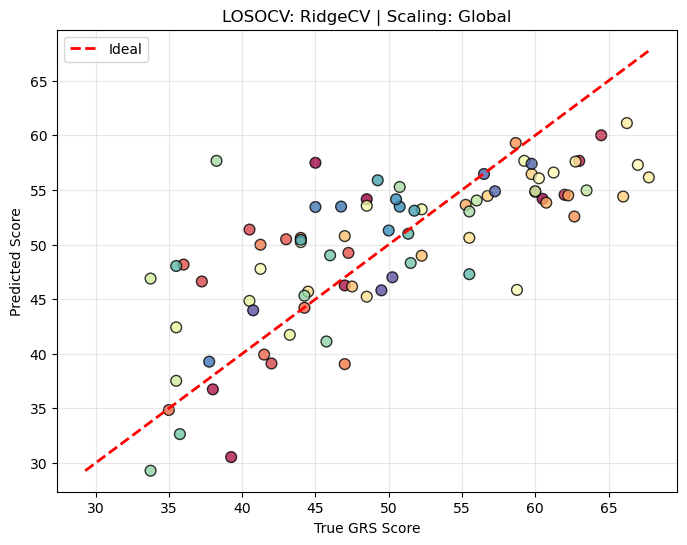

In [12]:
_, _, _ = evaluate_loso_model(df_full, top_features, extra_features=['velocity_corr'], model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

# Take Different Cases into account

- With Dummy Case variable
- By standarizing the relevant features by case

In [13]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_full['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_full.columns):
    df_full = pd.concat([df_full, df_case_onehot], axis=1)

In [14]:
candidate_features = list(set(candidate_features + list(df_case_onehot.columns)))
df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, test_other_pcs=False)
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.72it/s]


,Feature,Type,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Selection_Stability
9,interhand_dist_mean,External,0.066120,0.012077,-0.154808,0.642857
0,Case_1,External,0.063210,0.005594,-0.203241,0.535714
2,Case_3,External,0.062518,0.007185,0.241211,0.500000
12,mean_abs_angle_change_Left,External,0.058072,0.010712,-0.149506,0.321429
10,interhand_dist_std,External,0.046665,0.005382,-0.092400,0.000000
23,rms_accel_Left,External,0.043001,0.008104,-0.128575,0.000000
15,mean_velocity_Right,External,0.041544,0.007243,-0.040997,0.000000
24,rms_accel_Right,External,0.036392,0.007055,-0.031566,0.000000
34,workspace_area_Left,External,0.035452,0.006707,-0.101002,0.000000
22,pose_variability_Right,External,0.035247,0.005804,0.068663,0.000000


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 37.34it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7554 | MAE: 4.9869 | MAE STD: 3.8956 | R2: 0.5378


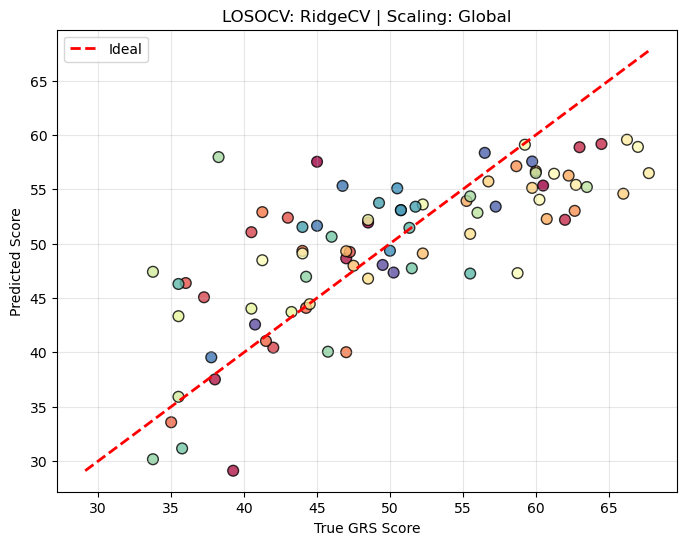

In [15]:
_, _, _ = evaluate_loso_model(df_full, top_features, extra_features=['velocity_corr', 'Case_3', 'Case_1'], model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

### Standarize by Case

While case-wise standardization is theoretically ideal for removing task-confounds, the limited sample size per task (N=27) likely introduces instability in the feature distributions. A Dummy Variable approach was adopted instead, as it allowed the model to account for baseline shifts in task difficulty (intercept) while maintaining the stability of the global kinematic distributions (slopes).


In [16]:
# first over the entire feature set and verify if it affect correlations with scores
to_standardize_by_case = all_features

df_full_standardized = df_full.copy()

# Ensure float dtype upfront
df_full_standardized[to_standardize_by_case] = (
    df_full_standardized[to_standardize_by_case].astype(float)
)

groups = df_full_standardized.groupby('Case_Number')

for _, df_group in tqdm(groups, desc="Standardizing by case"):
    idx = df_group.index
    means = df_group[to_standardize_by_case].mean()
    stds = df_group[to_standardize_by_case].std()

    valid = stds > 0
    df_full_standardized.loc[idx, valid.index[valid]] = (
        (df_group.loc[:, valid.index[valid]] - means[valid]) / stds[valid]
    )

leakage_free_correlation_analysis(df_full_standardized, all_features, n=6)

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 47.59it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
18,num_reversals_Right,-0.725112,0.010781,-0.752104,-0.711649,1.000000
16,nmu_peaks_Right,-0.709154,0.011462,-0.736817,-0.693360,1.000000
34,total_path_Right,-0.698112,0.012828,-0.728208,-0.683815,1.000000
30,total_angular_path_Right,-0.663771,0.012580,-0.693691,-0.649368,0.928571
31,total_duration_Left,-0.652501,0.014216,-0.691357,-0.632537,1.000000
32,total_duration_Right,-0.652039,0.014253,-0.690690,-0.632025,0.928571
17,num_reversals_Left,-0.626626,0.014658,-0.655255,-0.588548,0.071429
15,nmu_peaks_Left,-0.619708,0.015185,-0.651293,-0.589966,0.000000
8,ldlj_smoothness_Left,0.616842,0.017234,0.585957,0.672914,0.035714
9,ldlj_smoothness_Right,0.607195,0.012326,0.582100,0.630879,0.000000


Final Thesis Narrative

If I were writing this up, I would frame the Final Baseline as The "Two-Factor" Theory of Surgical Skill:

Factor 1: Efficiency (PC1)

Captures speed, path length, economy of motion.

Explains ~49% of the variance.

Factor 2: Bimanual Coordination (Velocity Correlation)

Captures how well the hands work together.

Explains an additional ~4% of unique variance (Partial R 
2
 ).

Task Context (Case Number)

"While task difficulty does shift the baseline scores, we exclude it from the primary model to ensure the metrics remain task-agnostic and robust."

Verdict

You are ready. Drop Step 8 (or keep it as a "secondary analysis" in the discussion), stick to the PC1 + Velocity Corr hybrid, and proceed. This is a very clean, defensible baseline.

In [17]:
# store the dataframe with only the top features
df_full[['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr'] + top_features].to_csv("data/metrics/top_features_df.csv", index=False)